In [1]:
import sklearn

In [1]:
from sklearn.preprocessing import StandardScaler

import joblib

# Load scaler later
scaler = joblib.load('/work/y_scaler_f_correct_scale.pkl')

In [7]:

import numpy as np

arr = np.array(pred_values)
np.save('markov_predictions.npy', arr)

NameError: name 'pred_values' is not defined

In [134]:
arr = np.array(true_values)
np.save('true_values.npy', arr)

In [7]:
!pip install statsmodels
!pip install hmmlearn 
import numpy as np
import pandas as pd
from hmmlearn.hmm import GaussianHMM
import statsmodels.api as sm
# Load data
y = pd.read_csv("y_f_correct_scale.csv", index_col=0)
X = pd.read_csv("X_f_correct_scale.csv", index_col=0)
X = X.drop("DS", axis=1)
X = X.drop("DPR", axis=1)


X = X[0:1383]
y = y[0:1383]

from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=24)


[notice] A new release of pip is available: 23.0.1 -> 25.1.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 23.0.1 -> 25.1.1
[notice] To update, run: pip install --upgrade pip


In [10]:
import numpy as np
import pandas as pd
from hmmlearn.hmm import GaussianHMM
import statsmodels.api as sm

# Define the features explicitly
features = ["VIX", "STR", "MKT", "Jump","RV_day", "RV_week", "RV_month", "SPX Index - Volume"]

# Dicts to store models
hmm_models = {}
har_models = {}

for n in range(2, 11):
    print(f"\n===== Fitting HMM with {n} regimes =====")
    hmm_model = GaussianHMM(n_components=n, covariance_type='full', n_iter=200, random_state=24)
    hmm_model.fit(X_train)
    hmm_models[n] = hmm_model

    print("Transition matrix:")
    print(hmm_model.transmat_)

    # Predict regimes on training set
    hidden_states = hmm_model.predict(X_train)

    har_models[n] = {}

    for regime in range(n):
        idx = (hidden_states == regime)
        X_regime = X_train[idx]
        y_regime = y_train[idx]

        if len(y_r6egime) == 0:
            print(f"Regime {regime} has no data, skipping HAR fit.")
            continue

        X_regime_df = pd.DataFrame(X_regime, columns=features)

        # Add constant explicitly
        X_regime_const = sm.add_constant(X_regime_df, has_constant='add')

        # Debug info
        print(f"Training regime {regime}: X shape = {X_regime_const.shape}, y length = {len(y_regime)}")

        har_model = sm.OLS(y_regime, X_regime_const).fit()
        har_models[n][regime] = har_model

        print(f"Beta coefficients for regime {regime} with {n} regimes:")
        print(har_model.params)

        
def predict_spx(X_new, n, hmm_models=hmm_models, har_models=har_models, features=features):
    """
    Predict SPX using the HMM + HAR models dictionaries.

    Parameters:
    - X_new: pd.DataFrame or np.ndarray with features matching `features`
    - n: number of regimes
    - hmm_models: dict of fitted GaussianHMM models
    - har_models: dict of HAR OLS models per regime
    - features: list of feature names

    Returns:
    - preds: np.ndarray of predictions
    """
    if not isinstance(X_new, pd.DataFrame):
        X_new = pd.DataFrame(X_new, columns=features)

    hmm_model = hmm_models[n]

    hidden_states = hmm_model.predict(X_new.values)

    preds = np.zeros(len(X_new))

    for regime in range(n):
        idx = (hidden_states == regime)
        if np.sum(idx) == 0:
            continue

        har_model = har_models[n].get(regime, None)
        if har_model is None:
            preds[idx] = np.nan
            continue

        X_regime = X_new.loc[idx, features]

        # Add constant explicitly
        X_regime_const = sm.add_constant(X_regime, has_constant='add')

        # Reorder columns exactly as training exog names
        expected_cols = har_model.model.exog_names
        X_regime_const = X_regime_const.reindex(columns=expected_cols)

        # Debug prints
        print(f"Predict regime {regime}: X shape = {X_regime_const.shape}, expected params length = {len(har_model.params)}")

        preds_here = har_model.predict(X_regime_const)

        # Check shape match before assignment
        if preds_here.shape[0] != np.sum(idx):
            raise ValueError(f"Shape mismatch: preds_here length {preds_here.shape[0]} != idx sum {np.sum(idx)}")

        preds[idx] = preds_here

    return preds


===== Fitting HMM with 2 regimes =====
Transition matrix:
[[0.73900837 0.26099163]
 [0.67984771 0.32015229]]
Training regime 0: X shape = (803, 9), y length = 803
Beta coefficients for regime 0 with 2 regimes:
const                -0.165743
VIX                   0.477526
STR                  -0.033138
MKT                  -0.010848
Jump                 -1.750692
RV_day                0.305159
RV_week               0.279204
RV_month             -0.118859
SPX Index - Volume   -0.002479
dtype: float64
Training regime 1: X shape = (303, 9), y length = 303
Beta coefficients for regime 1 with 2 regimes:
const                 0.070843
VIX                   0.800269
STR                  -0.029060
MKT                  -0.039951
Jump                 -0.438596
RV_day                0.402535
RV_week              -0.110022
RV_month             -0.123354
SPX Index - Volume    0.048984
dtype: float64

===== Fitting HMM with 3 regimes =====
Transition matrix:
[[0.52190032 0.11271292 0.36538677]
 [0.4

In [13]:
from sklearn.metrics import mean_squared_error

for n in range(2, 11):
    print(f"\n===== Fitting HMM with {n} regimes =====")
    preds = predict_spx(X_val, n)
    mse = mean_squared_error(y_val, preds)
    print(f"MSE = {mse}")


===== Fitting HMM with 2 regimes =====
Predict regime 0: X shape = (177, 9), expected params length = 9
Predict regime 1: X shape = (100, 9), expected params length = 9
MSE = 0.16019614857326794

===== Fitting HMM with 3 regimes =====
Predict regime 0: X shape = (117, 9), expected params length = 9
Predict regime 1: X shape = (39, 9), expected params length = 9
Predict regime 2: X shape = (121, 9), expected params length = 9
MSE = 0.16846446358094083

===== Fitting HMM with 4 regimes =====
Predict regime 0: X shape = (122, 9), expected params length = 9
Predict regime 1: X shape = (76, 9), expected params length = 9
Predict regime 2: X shape = (73, 9), expected params length = 9
Predict regime 3: X shape = (6, 9), expected params length = 9
MSE = 0.2126511968851476

===== Fitting HMM with 5 regimes =====
Predict regime 0: X shape = (97, 9), expected params length = 9
Predict regime 1: X shape = (10, 9), expected params length = 9
Predict regime 2: X shape = (52, 9), expected params le

In [19]:
mse = mean_squared_error(y_val, predict_spx(X_val, 2)) 

Predict regime 0: X shape = (108, 11), expected params length = 11
Predict regime 1: X shape = (169, 11), expected params length = 11


In [19]:
predict_spx(X, 2)

X_new = pd.DataFrame(X, columns=features)

# To get the hidden states (regime labels) for the 3-regime model:
hidden_states_2 = hmm_models[2].predict(X_new.values)

# Print unique regime labels assigned
print("Hidden states (regime labels) for 2-regime model:")
print(np.unique(hidden_states_2))

# Optional: attach regimes to X_new
X_new_with_regimes = X_new.copy()
X_new_with_regimes["Regime"] = hidden_states_2
print(X_new_with_regimes.head())
X_new_with_regimes.to_csv("X_new_with_regimes.csv", index=True)

Predict regime 0: X shape = (979, 9), expected params length = 9
Predict regime 1: X shape = (404, 9), expected params length = 9
Hidden states (regime labels) for 2-regime model:
[0 1]
                 VIX       STR       MKT      Jump    RV_day   RV_week  \
Date                                                                     
2014-05-01 -0.673881  0.722625 -0.153662 -0.182319 -0.578342 -0.407295   
2014-05-02 -0.721012  0.125126 -0.153662 -0.178177 -0.434412 -0.431444   
2014-05-05 -0.668337 -0.239450  0.132195  0.004175 -0.052392 -0.450151   
2014-05-06 -0.597640 -0.654662 -0.832097 -0.156201 -0.440151 -0.454107   
2014-05-07 -0.653088 -0.634407  0.464762 -0.139607  0.098178 -0.320913   

            RV_month  SPX Index - Volume  Regime  
Date                                              
2014-05-01 -0.410032           -0.654865       1  
2014-05-02 -0.409147           -0.661422       0  
2014-05-05 -0.369150           -0.881856       1  
2014-05-06 -0.355477           -0.622808

In [22]:
mse

0.1596390842011258

In [91]:
from sklearn.preprocessing import StandardScaler

import joblib

# Load scaler later
scaler = joblib.load('/work/y_scaler_combined_new.pkl')

/root/venv/lib/python3.10/site-packages/sklearn/base.py:329: UserWarning: Trying to unpickle estimator StandardScaler from version 1.3.2 when using version 1.1.3. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [25]:
from sklearn.metrics import mean_absolute_percentage_error
mape = mean_absolute_percentage_error(scaler.inverse_transform(np.array(predict_spx(X_val, 2)).reshape(-1, 1)), scaler.inverse_transform(np.array(y_val).reshape(-1, 1)))
print(f"Mean Absolute Percentage Error (MAPE): {mape:.6f}")
print(f"MAPE as percentage: {mape * 100:.2f}%")

Predict regime 0: X shape = (108, 11), expected params length = 11
Predict regime 1: X shape = (169, 11), expected params length = 11
Mean Absolute Percentage Error (MAPE): 0.275359
MAPE as percentage: 27.54%


In [28]:
pred_y = scaler.inverse_transform(np.array(predict_spx(X_val,2)).reshape(-1, 1))
true_y = scaler.inverse_transform(np.array(y_val).reshape(-1, 1))

Predict regime 0: X shape = (108, 11), expected params length = 11
Predict regime 1: X shape = (169, 11), expected params length = 11


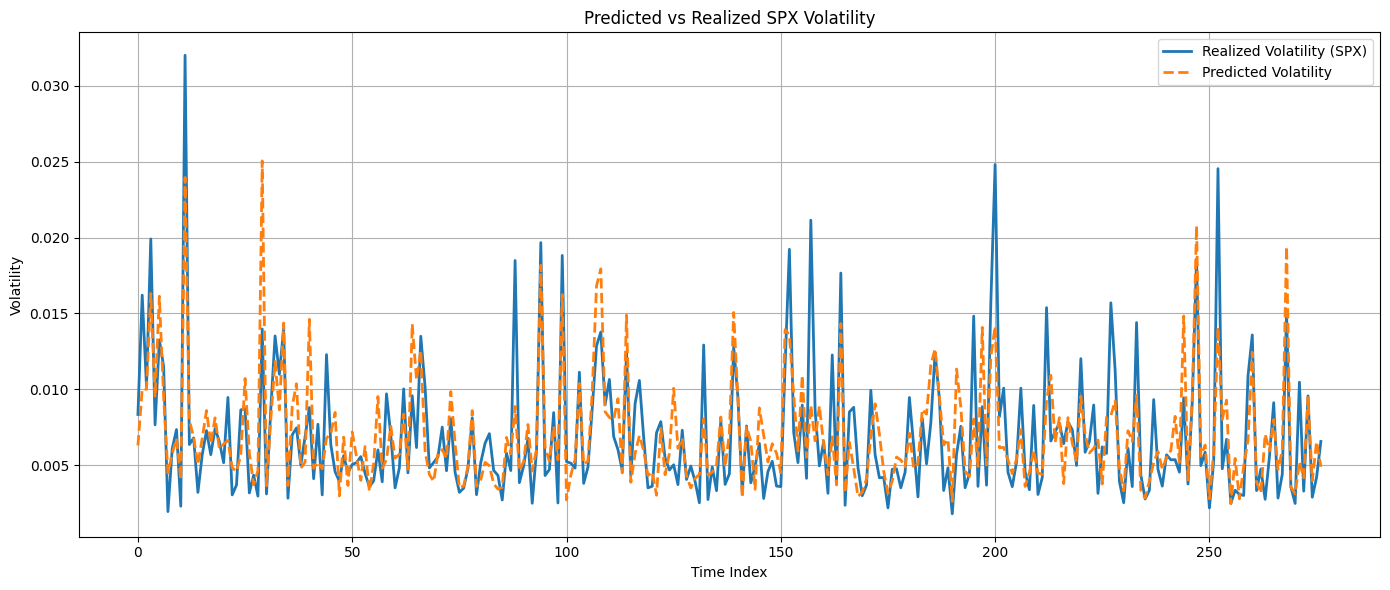

In [31]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(14, 6))
plt.plot(true_y, label='Realized Volatility (SPX)', linewidth=2)
plt.plot(pred_y, label='Predicted Volatility', linewidth=2, linestyle='--')
plt.title('Predicted vs Realized SPX Volatility')
plt.xlabel('Time Index')
plt.ylabel('Volatility')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [34]:
# Convert to correct shape & evaluate
import numpy as np
import joblib
from sklearn.metrics import mean_squared_error


# Reshape and inverse transform
pred_y = scaler.inverse_transform(np.array(predict_spx(X_val,2)).reshape(-1, 1))
true_y = scaler.inverse_transform(np.array(y_val).reshape(-1, 1))

mse = mean_squared_error(pred_y, true_y)

print(f"Mean Squared Error (MSE): {mse:.8f}")

Predict regime 0: X shape = (108, 11), expected params length = 11
Predict regime 1: X shape = (169, 11), expected params length = 11
Mean Squared Error (MSE): 0.00000750
